# Лабораторная работа: Машинное обучение и Визуализация данных (Matplotlib)

## Цели работы
1. **Визуализация (Matplotlib)**: построение базовых (plot, scatter) и составных графиков (subplots), гистограмм распределения ошибок.
2. **Машинное обучение (Scikit-Learn)**: применение **Linear Regression** для предсказания эффективности экранирования (SE).
3. **Анализ физики**: проверка гипотезы о линейной зависимости SE от магнитной проницаемости ($\mu_r$) и нелинейной зависимости от толщины экрана ($t$).

---

## 1. Теоретический блок: Физика экрана

Мы продолжаем работу со строгой аналитической моделью (Метод матриц передачи).
В этот раз мы исследуем экран со следующими параметрами:
- **Удельная проводимость ($\sigma$)**: $5.8 \times 10^7$ См/м (фиксирована)
- **Диэлектрическая проницаемость ($\varepsilon_r$)**: $1$ (фиксирована)
- **Толщина ($t$)**: $0.1$ мм ($10^{-4}$ м) (фиксирована в первой части)
- **Магнитная проницаемость ($\mu_r$)**: варьируется от 10 до 100.

**Диапазоны частот:**
Для анализа мы разделили частоты на три диапазона:
1. **Низкий**: 10 кГц - 10 МГц
2. **Средний**: 10 МГц - 1 ГГц
3. **Высокий**: 1 ГГц - 10 ГГц

Лектор выдвинул гипотезу: *В рамках заданных диапазонов и фиксированной толщины зависимость SE от $\mu_r$ близка к линейной. Если же менять толщину $t$, линейная регрессия перестанет справляться.*

---

## 2. Теория Data Science: Линейная регрессия и Ошибки

**Линейная регрессия (Linear Regression)** — алгоритм, который пытается провести прямую линию через облако точек так, чтобы суммарная ошибка была минимальной. Уравнение модели: $y = w \cdot x + b$.

Для визуального анализа качества модели часто используют **составные графики (Subplots)**:
- На левом графике строят диаграмму рассеяния (Scatter plot) истинных значений против предсказанных.
- На правом графике строят гистограмму (Histogram) распределения ошибок (разницы между предсказанием и фактом). У хорошей модели ошибка распределена вокруг нуля (колокол Гаусса).

---
## 3. Обучающие примеры (НЕ РЕДАКТИРОВАТЬ)

В этом разделе показаны основы работы с библиотекой **Matplotlib** для построения графиков. Запустите ячейки и изучите код.

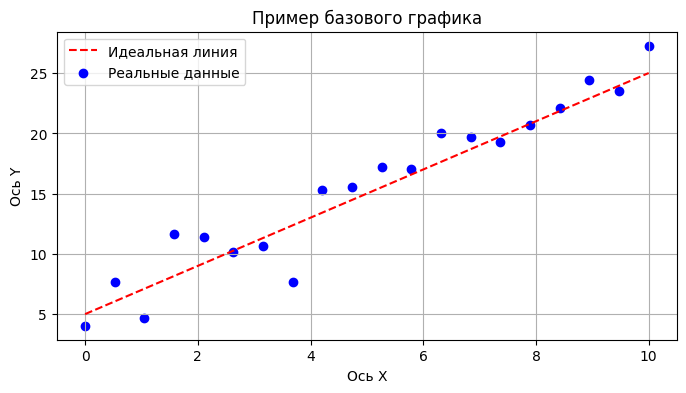

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# === ПРИМЕР 1: Базовые графики ===
x_ex = np.linspace(0, 10, 20)
y_ex = 2 * x_ex + 5 + np.random.normal(0, 2, 20)

plt.figure(figsize=(8, 4))
# Линия (plot)
plt.plot(x_ex, 2 * x_ex + 5, color='red', linestyle='--', label='Идеальная линия')
# Точки (scatter)
plt.scatter(x_ex, y_ex, color='blue', marker='o', label='Реальные данные')

plt.title('Пример базового графика')
plt.xlabel('Ось X')
plt.ylabel('Ось Y')
plt.legend()
plt.grid(True)
plt.show()

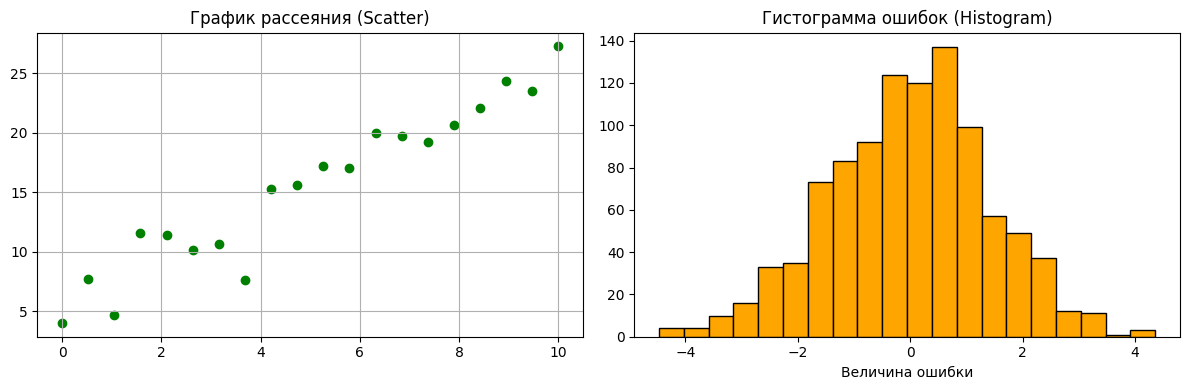

In [88]:
# === ПРИМЕР 2: Составные графики (Subplots) ===
errors_ex = np.random.normal(0, 1.5, 1000) # Имитация ошибок модели

# Создаем фигуру с 1 строкой и 2 колонками. axes - массив осей
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Левый график (axes[0])
axes[0].scatter(x_ex, y_ex, color='green')
axes[0].set_title('График рассеяния (Scatter)')
axes[0].grid(True)

# Правый график (axes[1]) - Гистограмма
axes[1].hist(errors_ex, bins=20, color='orange', edgecolor='black')
axes[1].set_title('Гистограмма ошибок (Histogram)')
axes[1].set_xlabel('Величина ошибки')

plt.tight_layout() # Чтобы графики не наезжали друг на друга
plt.show()

---
## 4. Генерация данных (Блок преподавателя)
**Просто запустите эту ячейку.** Она содержит функцию расчёта SE и генерирует данные для основной части работы (Средний диапазон частот).

In [89]:
mu0 = 4.0 * np.pi * 1e-7
eps0 = 8.854187817e-12
Z0 = 376.73

def calc_shield_se(freq, table):
    """
    Расчёт эффективности экранирования (SE) методом матриц передачи.
    """
    if table.ndim == 1:
        table = table[np.newaxis, :]

    n_layers = table.shape[0]
    SE = np.zeros(len(freq))

    for i in range(len(freq)):
        w = 2.0 * np.pi * freq[i]
        A_total = np.eye(2, dtype=complex)

        for v in range(n_layers):
            mu_r, eps_r, sigma_v, t_v, mat_type = table[v]
            Ma = mu_r * mu0
            Ea = eps_r * eps0

            if int(mat_type) == 1:
                z = np.sqrt((1j * w * Ma) / (sigma_v + 1j * w * Ea))
                g = np.sqrt((1j * w * Ma) * (sigma_v + 1j * w * Ea))
            else:
                sig_comp = w * eps0 * np.imag(eps_r)
                z = (1 + 1j) * np.sqrt(w * Ma / (sig_comp + 1e-30))
                g = 1j * np.sqrt(w * Ma * (sig_comp + 1j * w * eps0 * np.real(eps_r)))

            A_layer = np.array([
                [np.cosh(g * t_v), z * np.sinh(g * t_v)],
                [np.sinh(g * t_v) / z, np.cosh(g * t_v)]
            ], dtype=complex)

            A_total = A_total @ A_layer

        T = 2 * Z0 / (A_total[1, 0] * Z0**2 + A_total[1, 1] * Z0 +
                       A_total[0, 0] * Z0 + A_total[0, 1])
        SE[i] = 20.0 * np.log10(np.abs(1.0 / T))

    return SE

# Фиксированные параметры по условию задачи
SIGMA = 5.8e7
EPS_R = 1.0
T_FIXED = 1e-4

# --- ГЕНЕРАЦИЯ ДЛЯ ГРАФИКОВ (Спектры) ---
freq_mid = np.linspace(1e+3, 1e+7, 1001) # 1 кГц - 10 МГц
mu_for_plots = [10, 30, 50, 70, 100]
se_spectra = {}
for m in mu_for_plots:
    layer = np.array([m, EPS_R, SIGMA, T_FIXED, 1])
    se_spectra[m] = calc_shield_se(freq_mid, layer)

# --- ГЕНЕРАЦИЯ ДЛЯ ML (Датасет на фиксированной частоте из среднего диапазона) ---
np.random.seed(42)
target_freq_mid = 100e6 # 100 МГц
mu_dataset = np.random.uniform(10, 100, 200)
se_dataset = []
for m in mu_dataset:
    layer = np.array([m, EPS_R, SIGMA, T_FIXED, 1])
    se_dataset.append(calc_shield_se(np.array([target_freq_mid]), layer)[0])

df_mid = pd.DataFrame({'mu_r': mu_dataset, 'SE': se_dataset})
print("Данные успешно сгенерированы!")
print(f"Доступны: словарь 'se_spectra' (для графиков) и датафрейм 'df_mid' (для ML).")

Данные успешно сгенерированы!
Доступны: словарь 'se_spectra' (для графиков) и датафрейм 'df_mid' (для ML).


---
## 📝 Практика 1: Визуализация спектров (Matplotlib `plot`)
Используя сгенерированный преподавателем словарь `se_spectra` (где ключ - это $\mu_r$, а значение - массив SE), постройте семейство кривых.

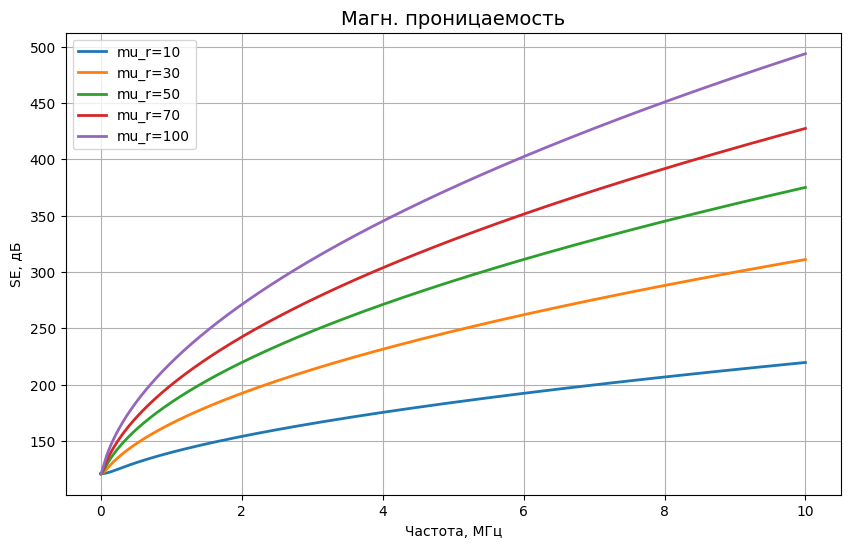

In [90]:
from re import T
plt.figure(figsize=(10, 6))

# В цикле проходимся по ключам (mu) и значениям (массивам SE) из словаря
for mu_val, se_array in se_spectra.items():
    # [Постройте график (plt.plot). Ось X: freq_mid / 1e6 (перевод в МГц), Ось Y: se_array]
    plt.plot(freq_mid/1e6,se_array, label=f"mu_r={mu_val}", linewidth=2)
    # [Добавьте параметр label=f'$\mu_r$ = {mu_val}' и толщину линии linewidth=2]
    # pass # удалите эту строку после написания кода

# [Добавьте сетку]
plt.grid(True)
# [Добавьте заголовок графика с размером шрифта fontsize=14]
plt.title("Магн. проницаемость", fontsize=14)
# [Подпишите ось X как "Частота, МГц", а ось Y как "SE, дБ"]
plt.xlabel("Частота, МГц")
plt.ylabel( "SE, дБ")
# [Отобразите легенду, указав title='Магн. проницаемость']
plt.legend()
plt.show()

---
## 📝 Практика 2: Обучение линейной регрессии
В датафрейме `df_mid` лежат значения магнитной проницаемости `mu_r` и эффективности `SE` для частоты 100 МГц.
Обучите модель предсказывать SE по значению mu_r.

In [91]:
# [1. Выделите признаки: X -'mu_r', y - столбцом 'SE']
X =df_mid[['mu_r']]
y =df_mid['SE']

# [2. Разделите на Train (80%) и Test (20%) с помощью train_test_split, random_state=42]
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

# [3. Создайте модель LinearRegression() и обучите её на тренировочных данных (.fit)]
model_mid =LinearRegression()
model_mid.fit(X_train, y_train)

# [4. Сделайте предсказание на тестовой выборке X_test (.predict)]
y_pred =model_mid.predict(X_test)

# [5. Вычислите R2 score, сравнив y_test и y_pred]
r2_mid =r2_score(y_test, y_pred)# замените 0.0 на вашу функцию

print("╔════════════════════════════════════════╗")
print(f"║ Качество модели (Средние частоты)      ║")
print(f"║ R² = {r2_mid:.4f}                            ║")
print("╚════════════════════════════════════════╝")

╔════════════════════════════════════════╗
║ Качество модели (Средние частоты)      ║
║ R² = 0.9852                            ║
╚════════════════════════════════════════╝


---
## 📝 Практика 3: Оценка модели составными графиками
Постройте фигуру с двумя графиками (1 строка, 2 колонки).

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4878/792413470.py:15: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title("Предсказание SE от $\mu_r$", fontsize=12)
/tmp/ipykernel_4878/792413470.py:16: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_xlabel("Магнитная проницаемость, $\mu_r$")
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


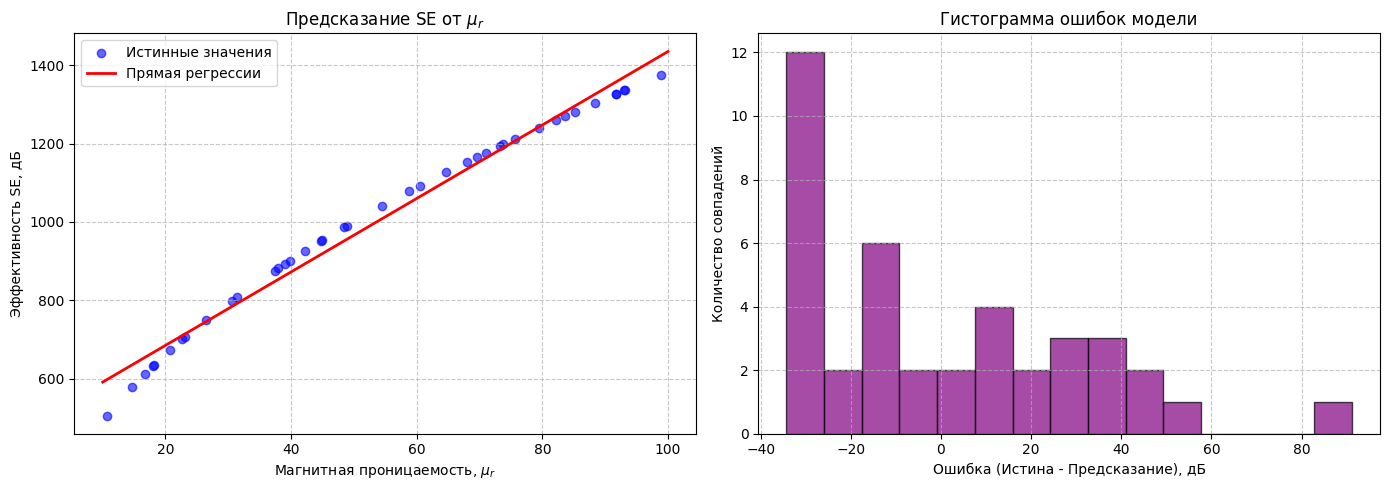

In [92]:
# [Создайте subplots: 1 строка, 2 колонки. Размер figsize=(14, 5)]
fig, axes =plt.subplots(1,2, figsize=(14,5))

# --- ЛЕВЫЙ ГРАФИК (axes[0]): Реальные данные и Линия регрессии ---
# [Постройте scatter plot для X_test и y_test (цвет синий, alpha=0.6, label='Истинные значения')]
axes[0].scatter(X_test,  y_test, color="blue", alpha=0.6, label='Истинные значения')

# Генерируем точки для отрисовки идеальной прямой линии модели
x_line = np.linspace(10, 100, 100).reshape(-1, 1)
y_line = model_mid.predict(x_line)

# [Отрисуйте линию регрессии (plot) по точкам x_line и y_line (цвет красный, linewidth=2, label='Прямая регрессии')]
axes[0].plot(x_line, y_line, color="red", linewidth=2, label='Прямая регрессии')

axes[0].set_title("Предсказание SE от $\mu_r$", fontsize=12)
axes[0].set_xlabel("Магнитная проницаемость, $\mu_r$")
axes[0].set_ylabel("Эффективность SE, дБ")
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

# --- ПРАВЫЙ ГРАФИК (axes[1]): Гистограмма ошибок ---
# [Рассчитайте массив ошибок (разница между y_test и y_pred)]
errors =y_pred-y_test

# [Постройте гистограмму (hist) для массива errors. Параметры: bins=15, color='purple', edgecolor='black', alpha=0.7]
axes[1].hist(errors, bins=15, color='purple', edgecolor='black', alpha=0.7)

axes[1].set_title("Гистограмма ошибок модели", fontsize=12)
axes[1].set_xlabel("Ошибка (Истина - Предсказание), дБ")
axes[1].set_ylabel("Количество совпадений")
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
## 📝 Практика 4: Самостоятельная работа (Рандомный диапазон)
Сейчас скрипт случайным образом назначит вам один из двух оставшихся диапазонов (Низкий или Высокий). Ваша задача: повторить процесс обучения и построить график `scatter` с линией регрессии.

In [93]:
# --- ГЕНЕРАЦИЯ ВАРИАНТА ПРЕПОДАВАТЕЛЕМ ---
student_id = int(input("Введите ваш номер в списке группы (число): "))

np.random.seed(student_id)
is_low = np.random.choice([True, False])
variant_freq = 1e6 if is_low else 5e9 # 1 МГц (Низкий) или 5 ГГц (Высокий)
variant_name = "Низкий (1 МГц)" if is_low else "Высокий (5 ГГц)"

print(f"\n⚡ ВАШ ВАРИАНТ: {variant_name} диапазон")

mu_var = np.random.uniform(10, 100, 200)
se_var = []
for m in mu_var:
    layer = np.array([m, EPS_R, SIGMA, T_FIXED, 1])
    se_var.append(calc_shield_se(np.array([variant_freq]), layer)[0])

df_variant = pd.DataFrame({'mu_r': mu_var, 'SE': se_var})
df_variant=df_variant.dropna()
print("Датасет 'df_variant' готов к работе!")
print(df_variant.head())

Введите ваш номер в списке группы (число): 5

⚡ ВАШ ВАРИАНТ: Высокий (5 ГГц) диапазон
Датасет 'df_variant' готов к работе!
         mu_r           SE
0   14.966211  3654.817934
4   18.083893  4010.782865
6   41.872424  6068.850458
12  31.828636  5299.396322
14  19.981069  4212.492399


/tmp/ipykernel_4878/2934838046.py:33: RuntimeWarning: overflow encountered in cosh
  [np.cosh(g * t_v), z * np.sinh(g * t_v)],
/tmp/ipykernel_4878/2934838046.py:33: RuntimeWarning: overflow encountered in sinh
  [np.cosh(g * t_v), z * np.sinh(g * t_v)],
/tmp/ipykernel_4878/2934838046.py:33: RuntimeWarning: invalid value encountered in scalar multiply
  [np.cosh(g * t_v), z * np.sinh(g * t_v)],
/tmp/ipykernel_4878/2934838046.py:34: RuntimeWarning: overflow encountered in sinh
  [np.sinh(g * t_v) / z, np.cosh(g * t_v)]
/tmp/ipykernel_4878/2934838046.py:34: RuntimeWarning: invalid value encountered in scalar divide
  [np.sinh(g * t_v) / z, np.cosh(g * t_v)]
/tmp/ipykernel_4878/2934838046.py:34: RuntimeWarning: overflow encountered in cosh
  [np.sinh(g * t_v) / z, np.cosh(g * t_v)]
/tmp/ipykernel_4878/2934838046.py:37: RuntimeWarning: invalid value encountered in matmul
  A_total = A_total @ A_layer
/tmp/ipykernel_4878/2934838046.py:39: RuntimeWarning: invalid value encountered in scalar d

R2 Score: 0.9740


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


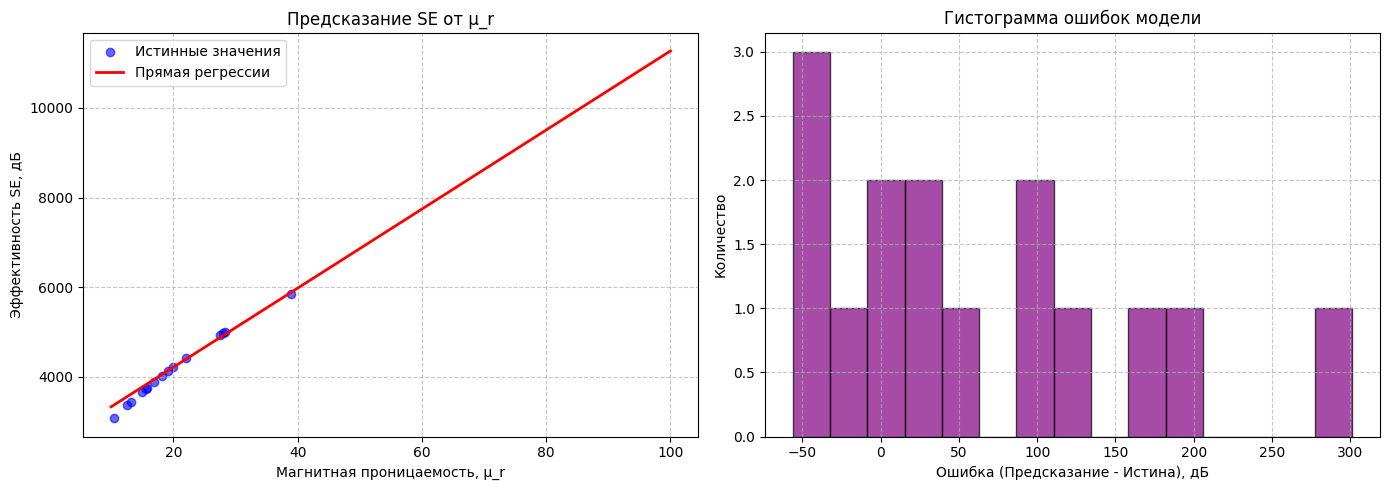

In [94]:
# === ВАШ КОД ДЛЯ ПРАКТИКИ 4 НИЖЕ ===

# 1. Выделите признаки X и y из df_variant, разделите на Train/Test (20% на тест)
X = df_variant[['mu_r']]      # 2D
y = df_variant['SE']          # 1D

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Обучите новую модель Линейной регрессии
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Предсказание и R2 score
y_pred = model.predict(X_test)
r2Score = r2_score(y_test, y_pred)

print("=" * 100)
print(f"R2 Score: {r2Score:.4f}")
print("=" * 100)

# 4. Постройте график: scatter + plot (красная линия предсказаний)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Левый график: регрессия
axes[0].scatter(X_test, y_test, color='blue', alpha=0.6, label='Истинные значения')
x_line = np.linspace(10, 100, 100).reshape(-1, 1)
y_line = model.predict(x_line)
axes[0].plot(x_line, y_line, color='red', linewidth=2, label='Прямая регрессии')
axes[0].set_title('Предсказание SE от μ_r', fontsize=12)
axes[0].set_xlabel('Магнитная проницаемость, μ_r')
axes[0].set_ylabel('Эффективность SE, дБ')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

# Правый график: гистограмма ошибок
errors = y_pred - y_test
axes[1].hist(errors, bins=15, color='purple', edgecolor='black', alpha=0.7)
axes[1].set_title('Гистограмма ошибок модели', fontsize=12)
axes[1].set_xlabel('Ошибка (Предсказание - Истина), дБ')
axes[1].set_ylabel('Количество')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


---
## 🌟 Практика 5 (Продвинутая): Усложнение физики (Влияние толщины)
Мы убедились, что SE почти линейно зависит от $\mu_r$ (R² > 0.95). Но что будет, если мы зафиксируем $\mu_r = 50$, а **толщину экрана ($t$) будем менять от 1 мкм до 50 мкм**?

Обучите линейную регрессию на признаке `thickness` и убедитесь по графику и метрике $R^2$, что линейная модель здесь **не подходит**.

In [95]:
# --- ГЕНЕРАЦИЯ ДАННЫХ С РАЗНОЙ ТОЛЩИНОЙ ---
t_values = np.linspace(1e-6, 50e-6, 200)
se_thick = []
for thick in t_values:
    layer = np.array([50.0, EPS_R, SIGMA, thick, 1])
    se_thick.append(calc_shield_se(np.array([100e6]), layer)[0])

df_thick = pd.DataFrame({'thickness': t_values * 1e6, 'SE': se_thick}) # thickness в мкм
print("Данные 'df_thick' с изменяемой толщиной готовы!")

# === ВАШ КОД НИЖЕ ===

# 1. Разделите df_thick на признак X ('thickness') и целевую переменную y ('SE')


# 2. Обучите LinearRegression на ВСЕХ данных (в этот раз без разделения на train/test для наглядности кривой)


# 3. Сделайте предсказание для всего массива X


# 4. Рассчитайте R2 score и выведите его через print (он должен сильно упасть!)


# 5. Постройте график: scatter (реальные точки) и plot (прямая линия предсказаний). Убедитесь, что линия не улавливает изгиб!



Данные 'df_thick' с изменяемой толщиной готовы!
